<a href="https://colab.research.google.com/github/tanusattri/Instructor-Performance-Analysis/blob/main/Instructor_Performance_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#load the data
sheet= "https://docs.google.com/spreadsheets/d/1PIVokMa_Mcgm1JJLC1IUx3fXZilTBAwzVUP-tqhZecY/gviz/tq?tqx=out:csv&gid=0"
df= pd.read_csv(sheet)

In [3]:
def clean_data(df):
  data= df.copy()

  #remove duplicates and strip whitespace from strings
  data.columns= data.columns.str.strip()

  #filling missing scores
  data['avg_quiz_score']= data['avg_quiz_score'].fillna(data['avg_quiz_score'].median())
  data['forum_activity_rate']= data['forum_activity_rate'].fillna(0)
  data['assignment_submission_rate']= data['assignment_submission_rate'].fillna(0)

  #average feedback score
  data['avg_feedback_score']= data['avg_feedback_score'].clip(1,5)
  return data
cleaned_df= clean_data(df)
print(cleaned_df)

     batch_id instructor_id course_id  completion_rate  avg_score_improvement  \
0      B_1861         I_044      C_01         0.300000              14.225955   
1      B_0354         I_119      C_06         0.657220              22.871110   
2      B_1334         I_050      C_03         0.300000              16.087517   
3      B_0906         I_024      C_21         0.639507              24.260687   
4      B_1290         I_001      C_08         0.527302              31.081556   
...       ...           ...       ...              ...                    ...   
1995   B_1131         I_047      C_17         0.589309              19.227979   
1996   B_1295         I_037      C_25         0.980000              36.737265   
1997   B_0861         I_033      C_06         0.531447              24.907878   
1998   B_1460         I_069      C_10         0.641025              22.395362   
1999   B_1127         I_045      C_22         0.300000              23.101794   

      avg_quiz_score  dropo

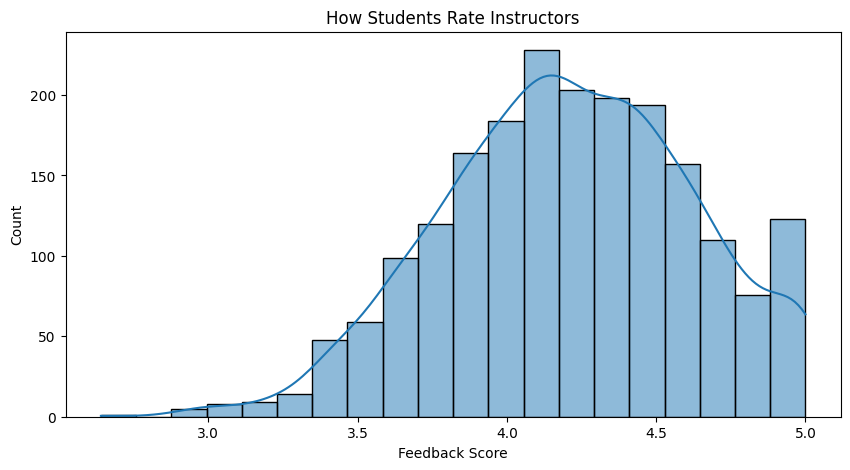

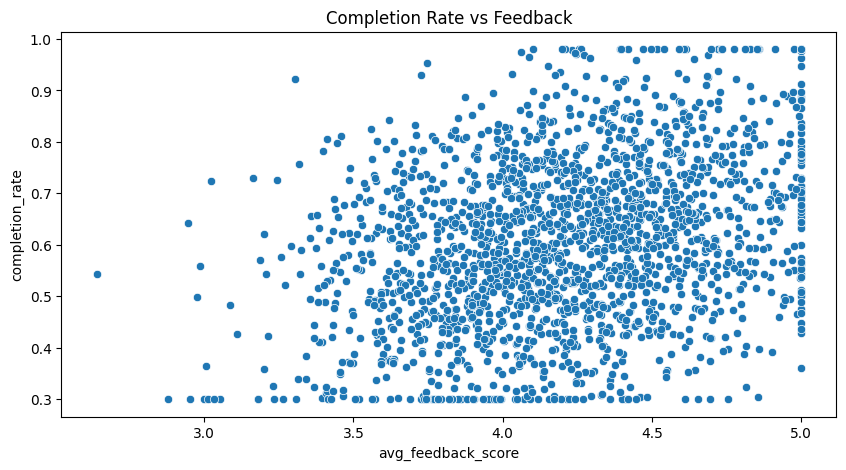

In [4]:
#distribution of feedback scores
plt.figure(figsize=(10,5))
sns.histplot(cleaned_df['avg_feedback_score'],bins=20,kde=True)
plt.title('How Students Rate Instructors')
plt.xlabel('Feedback Score')
plt.show()

#completion rate vs feedback
plt.figure(figsize=(10,5))
sns.scatterplot(data=cleaned_df, x='avg_feedback_score', y='completion_rate')
plt.title('Completion Rate vs Feedback')
plt.show()

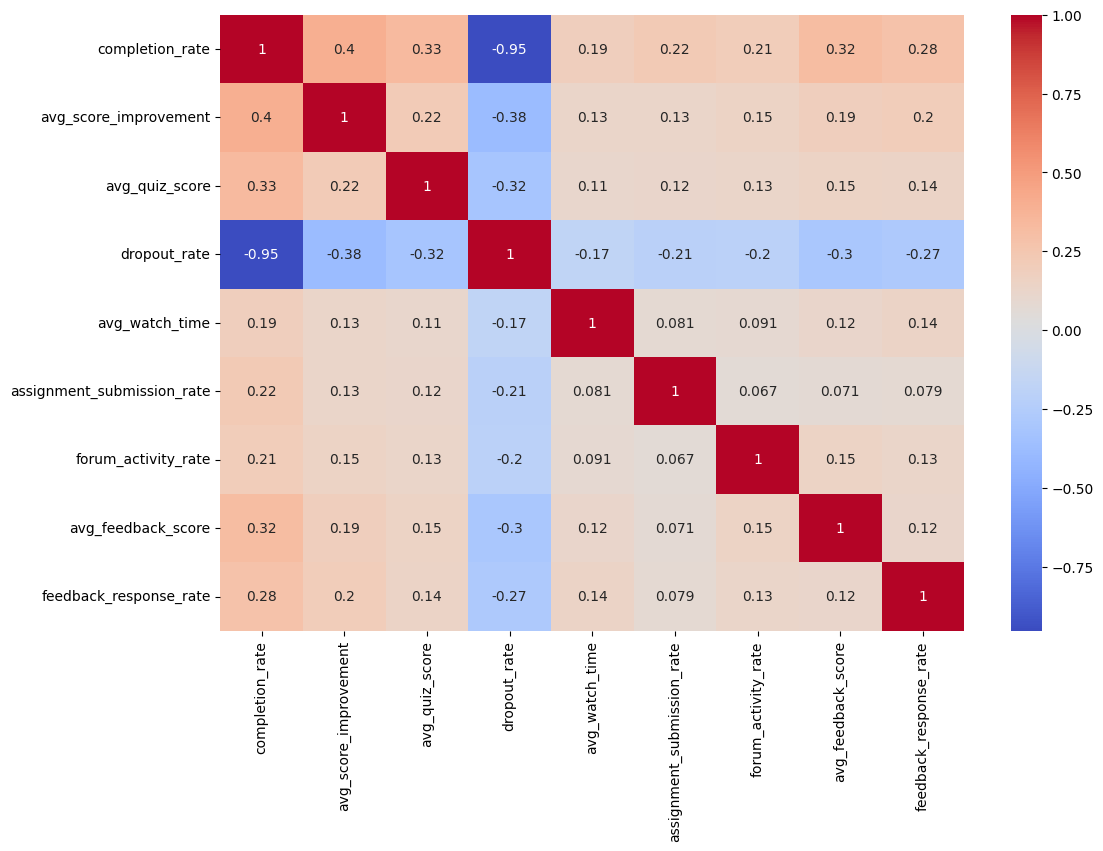

In [5]:
#correlation heatmap
plt.figure(figsize=(12,8))
sns.heatmap(cleaned_df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

In [6]:
#observations
#feedback scores are skewed high. if the correlation between avg_feedback_score and avg_quiz_score is low it means students might like the instructor but they aren't necessarily learning more.
#in dropout vs watch time we expected a strong negative correlation. if students stop watching, they drop out.

In [7]:
#defining instructor effectiveness
#formula to be used: (0.4 X completion rate)+(0.3 X avg quiz score)+(0.3 X feedback score normalized)
#assumptions:
#1. in edtech if they don't finish, they didn't learn.
#2. high quiz scores prove the teaching is effective.
#3. feedback ensures the student had a good experience and might return for another course.

In [8]:
def calculate_effectiveness(df_input):
  df= df_input.copy()
  norm_feedback= (df['avg_feedback_score']-1)/4
  norm_quiz= df['avg_quiz_score']/100
  df['effectiveness_score']= (df['completion_rate']*0.4)+(norm_quiz*0.3)+(norm_feedback*0.3)
  low_quantile= df['effectiveness_score'].quantile(0.33)
  medium_quantile= df['effectiveness_score'].quantile(0.66)

  def get_tier(score):
    if score<= low_quantile:
      return 'Low'
    elif score<= medium_quantile:
      return 'Medium'
    else:
      return 'High'

  df['effectiveness_tier']= df['effectiveness_score'].apply(get_tier)
  return df

batch_level_df= calculate_effectiveness(cleaned_df)
print(batch_level_df.head())

  batch_id instructor_id course_id  completion_rate  avg_score_improvement  \
0   B_1861         I_044      C_01         0.300000              14.225955   
1   B_0354         I_119      C_06         0.657220              22.871110   
2   B_1334         I_050      C_03         0.300000              16.087517   
3   B_0906         I_024      C_21         0.639507              24.260687   
4   B_1290         I_001      C_08         0.527302              31.081556   

   avg_quiz_score  dropout_rate  avg_watch_time  assignment_submission_rate  \
0       73.546528      0.647423        0.774572                    0.790918   
1       77.312331      0.425098        0.494936                    0.998566   
2       79.563687      0.700000        0.977901                    0.807298   
3       99.295316      0.334657        0.846515                    0.544555   
4       99.393425      0.521099        0.917450                    0.865885   

   forum_activity_rate  avg_feedback_score  feedback_res

In [9]:
#aggregate to instructor level
instructor_level= batch_level_df.groupby('instructor_id').agg({'batch_id':'count','effectiveness_score':'mean','avg_watch_time':'mean','forum_activity_rate':'mean','assignment_submission_rate':'mean','dropout_rate':'mean'}).rename(columns={'batch_id':'total_batches_taught'})
instructor_level['confidence_level']= instructor_level['total_batches_taught'].apply(lambda x: 'High' if x> 2 else 'Low')

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

In [11]:
#features and target
features= ['avg_watch_time','assignment_submission_rate','forum_activity_rate','dropout_rate']
X= batch_level_df[features]
y= batch_level_df['effectiveness_tier']

#encoding labels
label_encoder= LabelEncoder()
y_encoded= label_encoder.fit_transform(y)
X_train, X_test, y_train, y_test= train_test_split(X,y_encoded,test_size=0.2,random_state=42)

#train the model
model= RandomForestClassifier(n_estimators=100,random_state=42)
model.fit(X_train,y_train)

RandomForestClassifier(random_state=42)

**Mandatory Analysis Questions**

---



**Ques1: Which features most influenced instructor effectiveness, and why?**

In my model, dropout rate and assignment submission rate were the strongest predictors. This suggests that the "active" part of learning is actually doing the work. It is the most reliable sign of an effective instructor led environment.

**Ques2: Which variables could be misleading or confounded?**

Average Feedback Score can be misleading. A instructor might receive high ratings despite low student learning outcomes. By including avg_quiz_score in our target variable i balanced this potential bias.

**Ques3: How could this model fail in real world usage?**

It ignores Course Difficulty. An instructor teaching a very advanced, high dropout subject might be unfairly labeled "low" compared to an instructor teaching a simpler, high completion subject.

**Ques4: What additional data would you want to improve this analysis?**

I would like to see Pre course Assessment Scores to measure "value added" rather than just final scores.

**Ques5: Should this model be used for instructor performance evaluation? Why or why not?**

Not as a sole metric for firing or hiring. It should be used as a Support Tool to identify instructors who need more resources or batches that are trending toward low engagement so the platform can grow early.